# Unified Retrieval Comparison: BM25, Word2Vec, and Transformers

This notebook compares keyword, static-embedding, and contextual semantic retrieval on the same corpus and relevance judgments. It reports Recall@k, Precision@k, and MRR, inspects ranked results, and visualizes the transformer embedding space.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR / 'src'))
sys.path.insert(0, str(PROJECT_DIR / 'streamlit'))

from bm25_retriever import BM25Retriever
from evaluator import IRMetrics
from transformer_retriever import TransformerRetriever
from word2vec_retriever import Word2VecRetriever
from demo_data import CORPUS_TEXTS, DEMO_CORPUS, GROUND_TRUTH, SAMPLE_QUERIES

## Shared evaluation data

Every method receives exactly the same documents and queries. String ground-truth IDs are converted to the sequential integer IDs expected by the retrievers and evaluator.

In [2]:
query_texts = list(GROUND_TRUTH)
qrels = {
    query_id: {doc_id: 1 for doc_id in GROUND_TRUTH[query]}
    for query_id, query in enumerate(query_texts)
}
print(f'{len(CORPUS_TEXTS)} documents, {len(query_texts)} evaluated queries')

5 documents, 23 evaluated queries


## Metrics

- **Recall@k** is the fraction of all relevant documents found in the first *k* results.
- **Precision@k** is the fraction of the first *k* positions occupied by relevant documents.
- **MRR** averages the reciprocal rank of the first relevant result, rewarding systems that put a useful document near rank 1.

In [3]:
bm25 = BM25Retriever()
bm25.build_index(CORPUS_TEXTS)
bm25_results = bm25.retrieve(query_texts, k=20)
bm25_metrics = IRMetrics.evaluate_retrieval(bm25_results, qrels)
bm25_metrics

🔧 Building BM25 index...
✅ BM25 index built for 5 documents
🔍 Running BM25 retrieval for 23 queries...


Retrieving:   0%|          | 0/23 [00:00<?, ?it/s]

Retrieving: 100%|██████████| 23/23 [00:00<00:00, 10598.66it/s]

✅ Retrieved top-20 documents for 23 queries


{'Recall@1': np.float64(0.6304347826086957),
 'Recall@5': np.float64(1.0),
 'Recall@10': np.float64(1.0),
 'Precision@5': np.float64(0.21739130434782616),
 'MRR': np.float64(0.786231884057971)}

## Word2Vec training and hyperparameter optimization

Word2Vec is trained only on this small corpus, so results can vary substantially with its architecture and context window. The fixed seed in the retriever keeps this comparison reproducible.

In [4]:
parameter_candidates = [
    {'vector_size': 50, 'window': 5, 'min_count': 1, 'sg': 0, 'epochs': 30},
    {'vector_size': 100, 'window': 10, 'min_count': 1, 'sg': 1, 'epochs': 60},
    {'vector_size': 150, 'window': 15, 'min_count': 1, 'sg': 1, 'epochs': 100},
]
optimization = Word2VecRetriever.optimize_parameters(
    parameter_candidates, CORPUS_TEXTS, query_texts, qrels, IRMetrics
)
optimization['best_config'], optimization['best_metrics']

🔧 Starting Word2Vec Parameter Optimization
📋 Testing 3 configurations...

📋 Configuration 1/3
   Parameters: {'vector_size': 50, 'window': 5, 'min_count': 1, 'sg': 0, 'epochs': 30}
   📊 MRR: 0.8145 | Recall@5: 1.0000
   ✨ NEW BEST! (MRR improved: 0.8145)

📋 Configuration 2/3
   Parameters: {'vector_size': 100, 'window': 10, 'min_count': 1, 'sg': 1, 'epochs': 60}
   📊 MRR: 0.8623 | Recall@5: 1.0000
   ✨ NEW BEST! (MRR improved: 0.8623)

📋 Configuration 3/3
   Parameters: {'vector_size': 150, 'window': 15, 'min_count': 1, 'sg': 1, 'epochs': 100}


   📊 MRR: 0.8406 | Recall@5: 1.0000

🏆 OPTIMIZATION COMPLETE


({'vector_size': 100, 'window': 10, 'min_count': 1, 'sg': 1, 'epochs': 60},
 {'Recall@1': np.float64(0.7608695652173914),
  'Recall@5': np.float64(1.0),
  'Recall@10': np.float64(1.0),
  'Precision@5': np.float64(0.21739130434782616),
  'MRR': np.float64(0.8623188405797101)})

In [5]:
word2vec = Word2VecRetriever(**optimization['best_config'])
word2vec.build_index(CORPUS_TEXTS)
word2vec_results = word2vec.retrieve(query_texts, k=20)
word2vec_metrics = IRMetrics.evaluate_retrieval(word2vec_results, qrels)
word2vec_metrics

{'Recall@1': np.float64(0.7608695652173914),
 'Recall@5': np.float64(1.0),
 'Recall@10': np.float64(1.0),
 'Precision@5': np.float64(0.21739130434782616),
 'MRR': np.float64(0.8623188405797101)}

In [6]:
transformer = TransformerRetriever('all-MiniLM-L6-v2')
transformer.build_index(CORPUS_TEXTS)
transformer_results = transformer.retrieve(query_texts, k=20)
transformer_metrics = IRMetrics.evaluate_retrieval(transformer_results, qrels)
transformer_metrics

🤖 Loading transformer model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Model loaded: all-MiniLM-L6-v2
🧠 Building semantic index...


✅ Semantic index built for 5 documents
   Embedding dimension: 384
🔍 Running semantic retrieval for 23 queries...
✅ Retrieved top-20 documents using semantic similarity


{'Recall@1': np.float64(0.5434782608695652),
 'Recall@5': np.float64(1.0),
 'Recall@10': np.float64(1.0),
 'Precision@5': np.float64(0.21739130434782616),
 'MRR': np.float64(0.7123188405797102)}

## Final retrieval results and performance comparison

,Recall@1,Recall@5,Recall@10,Precision@5,MRR
BM25,0.630,1.000,1.000,0.217,0.786
Word2Vec,0.761,1.000,1.000,0.217,0.862
Transformer,0.543,1.000,1.000,0.217,0.712


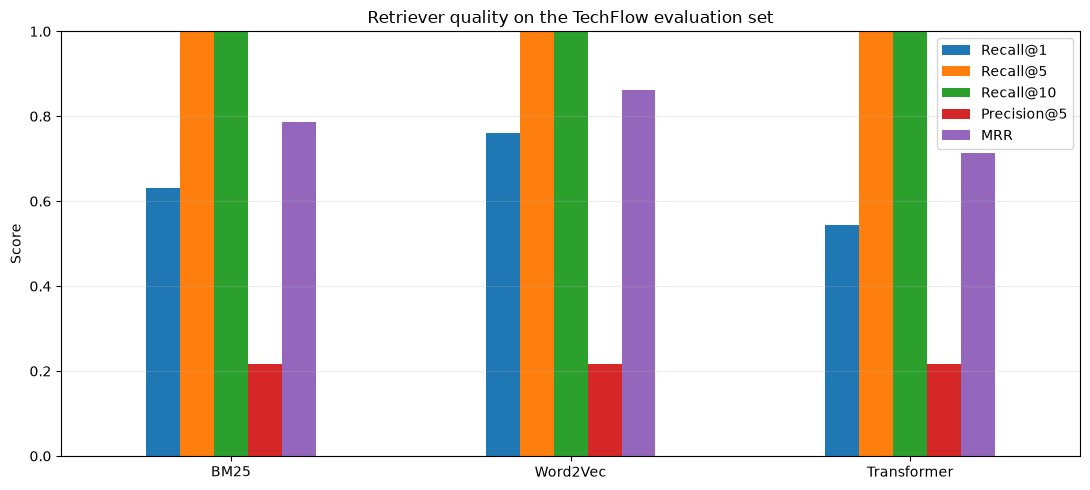

In [7]:
all_metrics = {
    'BM25': bm25_metrics,
    'Word2Vec': word2vec_metrics,
    'Transformer': transformer_metrics,
}
comparison = pd.DataFrame(all_metrics).T
display(comparison.style.format('{:.3f}').highlight_max(axis=0, color='#b7e4c7'))

comparison.plot(kind='bar', ylim=(0, 1), figsize=(11, 5), rot=0)
plt.title('Retriever quality on the TechFlow evaluation set')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [8]:
result_sets = {'BM25': bm25_results, 'Word2Vec': word2vec_results, 'Transformer': transformer_results}
rows = []
for query_id, query in enumerate(query_texts[:8]):
    relevant = set(qrels[query_id])
    for method, results in result_sets.items():
        top_three = results[query_id][:3]
        rows.append({
            'query': query, 'method': method, 'top_3_document_ids': top_three,
            'relevant_in_top_3': sorted(relevant.intersection(top_three)),
        })
pd.DataFrame(rows)

,query,method,top_3_document_ids,relevant_in_top_3
0,What does TechFlow AI do?,BM25,"[3, 4, 0]",[0]
1,What does TechFlow AI do?,Word2Vec,"[0, 2, 4]",[0]
2,What does TechFlow AI do?,Transformer,"[0, 1, 2]","[0, 1]"
3,Who is the CEO of TechFlow AI?,BM25,"[2, 0, 4]",[2]
4,Who is the CEO of TechFlow AI?,Word2Vec,"[2, 0, 4]",[2]
5,Who is the CEO of TechFlow AI?,Transformer,"[2, 0, 4]",[2]
6,What products does TechFlow AI offer?,BM25,"[1, 3, 4]",[1]
7,What products does TechFlow AI offer?,Word2Vec,"[0, 4, 1]",[1]
8,What products does TechFlow AI offer?,Transformer,"[0, 1, 2]",[1]
9,How much funding did TechFlow AI raise?,BM25,"[2, 3, 4]",[2]


## Transformer embedding-space visualization

PCA projects document and query embeddings into two dimensions. Nearby points have similar directions in the original embedding space, although a 2D projection inevitably discards information. Query labels should appear near documents about the same topic; visible groupings therefore give an intuitive, not definitive, view of semantic clustering.

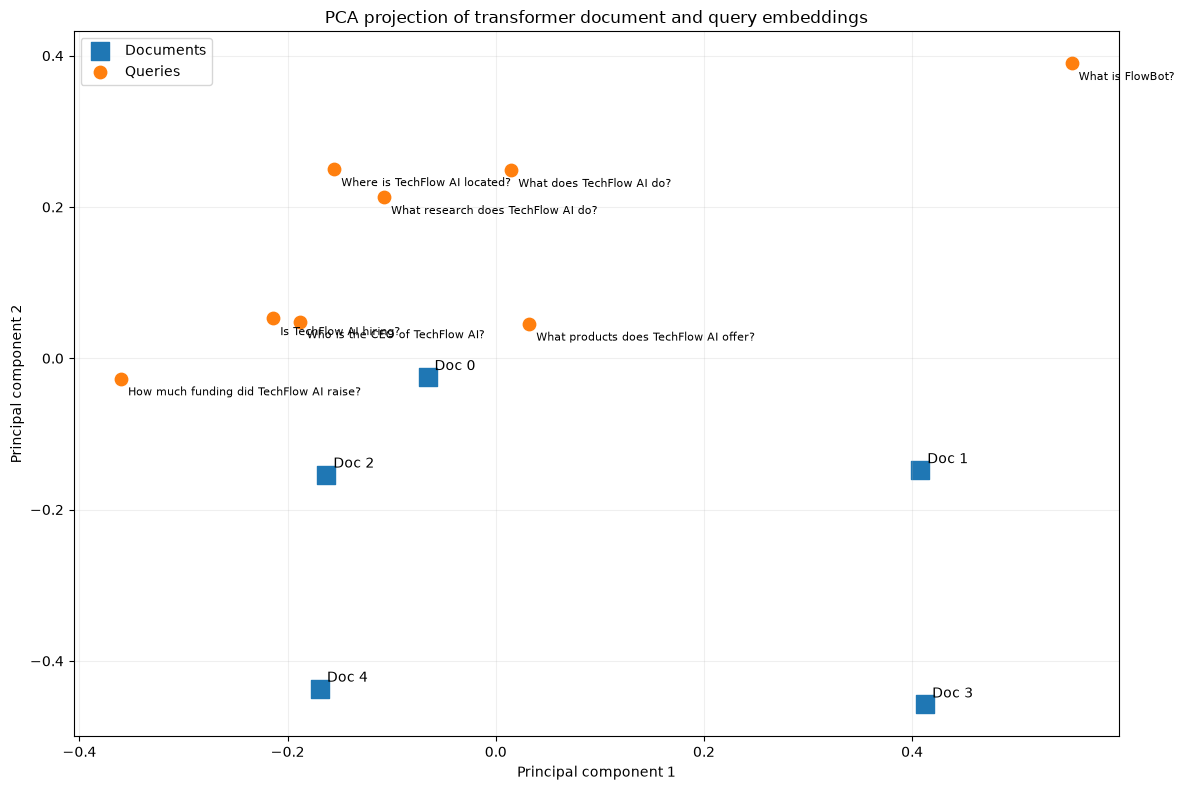

In [9]:
plot_queries = SAMPLE_QUERIES[:8]
query_embeddings = transformer.model.encode(
    plot_queries, convert_to_numpy=True, normalize_embeddings=True
)
combined = np.vstack([transformer.corpus_embeddings, query_embeddings])
points_2d = PCA(n_components=2).fit_transform(combined)
doc_points = points_2d[:len(CORPUS_TEXTS)]
query_points = points_2d[len(CORPUS_TEXTS):]

plt.figure(figsize=(12, 8))
plt.scatter(doc_points[:, 0], doc_points[:, 1], s=150, marker='s', label='Documents')
plt.scatter(query_points[:, 0], query_points[:, 1], s=80, marker='o', label='Queries')
for i, (x, y) in enumerate(doc_points):
    plt.annotate(f'Doc {i}', (x, y), xytext=(5, 5), textcoords='offset points')
for query, (x, y) in zip(plot_queries, query_points):
    plt.annotate(query, (x, y), xytext=(5, -12), textcoords='offset points', fontsize=8)
plt.title('PCA projection of transformer document and query embeddings')
plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## The retriever's role in RAG

A Retrieval-Augmented Generation system first encodes or scores a user's question, retrieves the most relevant documents, and adds those documents to the generator model's prompt. The language model then writes an answer grounded in that supplied evidence. Retrieval expands the generator's effective knowledge beyond its training data, while citations and constrained prompting can make answers easier to verify. The included Streamlit app runs all three retrievers over the same corpus and can pass each method's retrieved context to a generator, making the effect of retrieval quality directly visible.

This retrieve–augment–generate pattern underlies search-grounded assistants and coding or research tools such as ChatGPT, Copilot, and Perplexity, though production systems also add access control, reranking, source attribution, freshness checks, and safety layers. A retriever cannot guarantee factual answers: if it misses the needed evidence, the generator cannot reliably recover it.

The comparison illustrates the evolution of retrieval. **BM25** is fast and interpretable and excels when queries share distinctive terms with documents, but it cannot naturally connect paraphrases. **Word2Vec** adds word-level semantic similarity, yet every word has a single context-independent vector and averaging loses word order; it also needs enough domain text to learn useful relationships. **Transformer sentence embeddings** represent whole passages contextually and usually handle paraphrases and intent best, at the cost of model latency and memory. In practice, strong RAG systems often combine BM25 and dense retrieval, then rerank the merged candidates.